In [ ]:
import ast
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Data

In [ ]:
df = pd.read_csv('skincare_clean.csv')

In [ ]:
df.head()

,Age_Group,Skin_Type,Skin_Subtype,Sensitivity,Concern,Internal_Type,Ingredients,Concentrations,Effects,Ingredients_List,Skin_Sensitivity,Skin_Profile
0,14-18,Normal,Normal to Dry,Yes,Acne,Comedonal,Zinc PCA + Benzoyl Peroxide + Salicylic Acid,0.5% + 2% + 5%,"Controls sebum production, Kills acne-causing ...","['Zinc PCA', 'Benzoyl Peroxide', 'Salicylic Ac...",Normal - Sensitive,Comedonal_Normal
1,14-18,Normal,Normal to Dry,Yes,Acne,Inflammatory,Zinc PCA + Benzoyl Peroxide + Niacinamide,0.5% + 5% + 1%,"Controls sebum production, Kills acne-causing ...","['Zinc PCA', 'Benzoyl Peroxide', 'Niacinamide']",Normal - Sensitive,Inflammatory_Normal
2,14-18,Normal,Normal to Dry,Yes,Acne,Cyst,Benzoyl Peroxide + Niacinamide + Azelaic Acid,10% + 1% + 8%,"Kills acne-causing bacteria, Reduces inflammat...","['Benzoyl Peroxide', 'Niacinamide', 'Azelaic A...",Normal - Sensitive,Cyst_Normal
3,14-18,Normal,Normal to Dry,No,Acne,Comedonal,Green Tea Extract + Salicylic Acid + Niacinamide,1% + 0.5% + 10%,Provides antioxidant and anti-inflammatory ben...,"['Green Tea Extract', 'Salicylic Acid', 'Niaci...",Normal - Non-Sensitive,Comedonal_Normal
4,14-18,Normal,Normal to Dry,No,Acne,Inflammatory,Salicylic Acid + Benzoyl Peroxide + Zinc PCA,3% + 2% + 10%,"Unclogs pores and removes excess oil, Kills ac...","['Salicylic Acid', 'Benzoyl Peroxide', 'Zinc P...",Normal - Non-Sensitive,Inflammatory_Normal


Visualisasi data

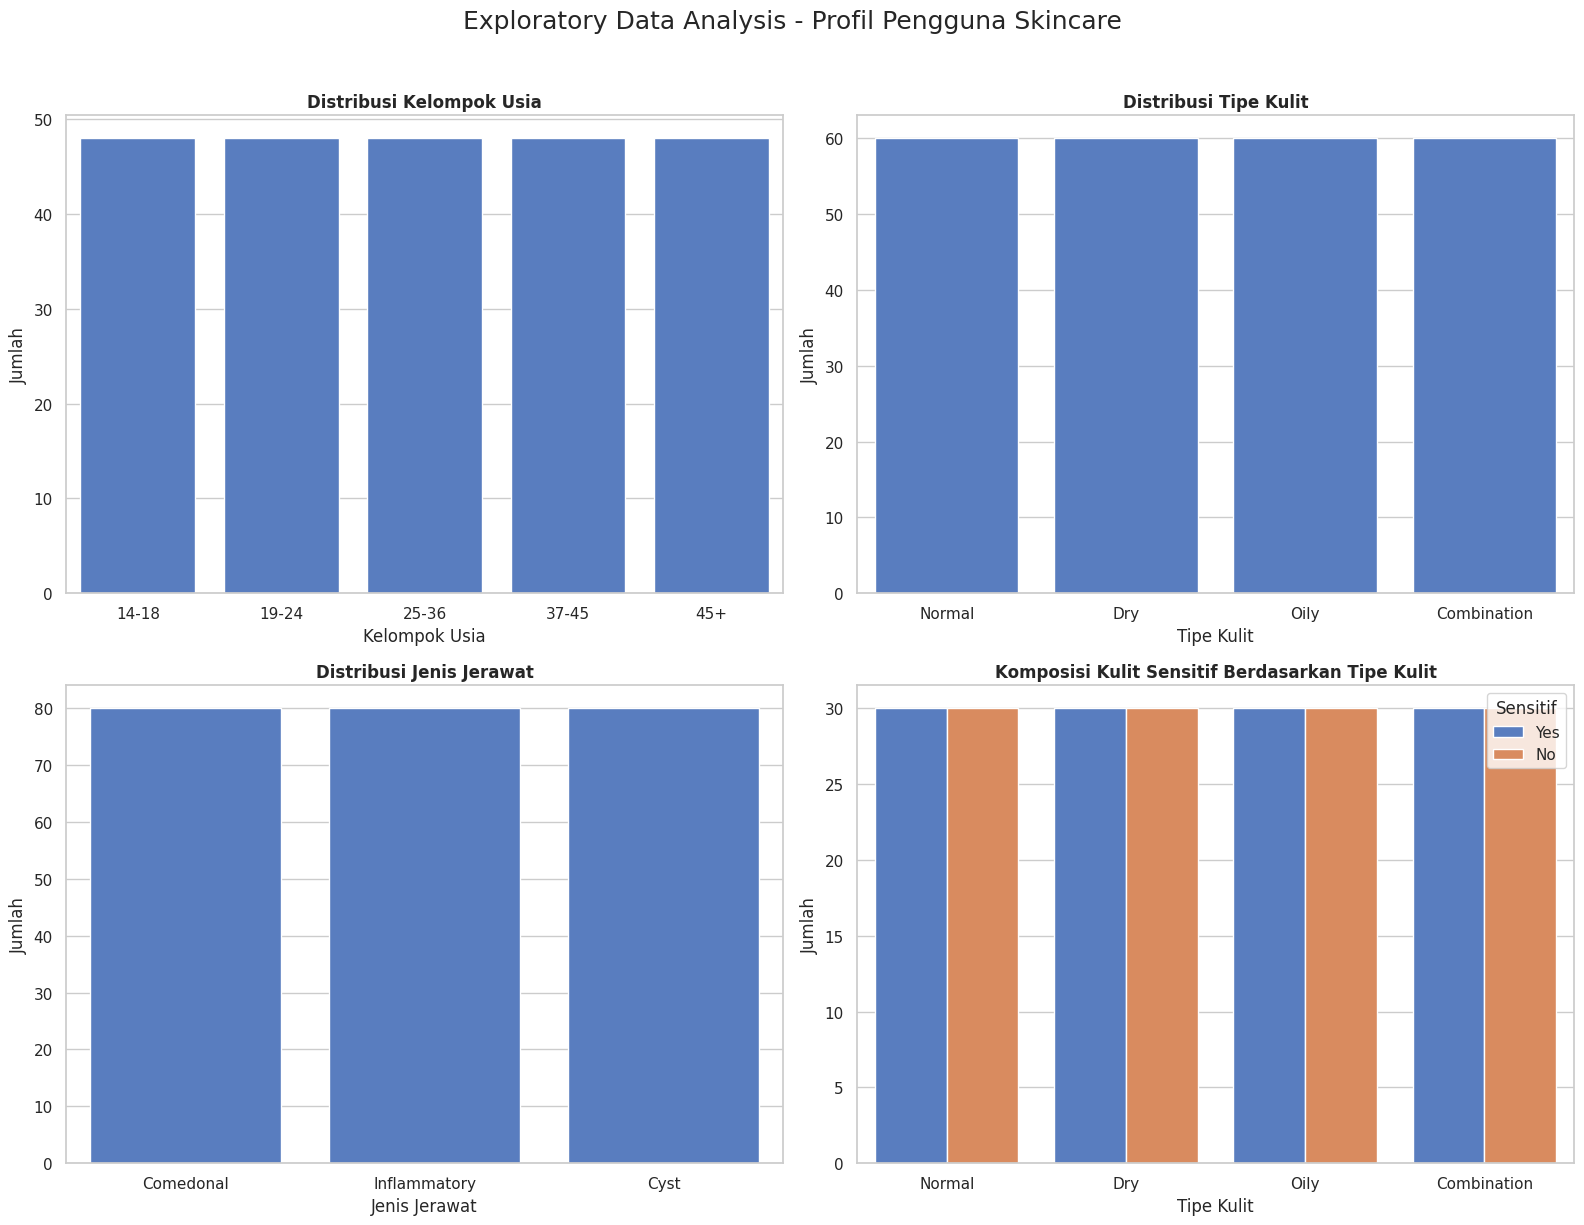

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis - Profil Pengguna Skincare', fontsize=18, y=1.02)

sns.countplot(data=df, x='Age_Group', ax=axes[0, 0], order=df['Age_Group'].value_counts().index)
axes[0, 0].set_title('Distribusi Kelompok Usia')
axes[0, 0].set_ylabel('Jumlah')
axes[0, 0].set_xlabel('Kelompok Usia')

sns.countplot(data=df, x='Skin_Type', ax=axes[0, 1], order=df['Skin_Type'].value_counts().index)
axes[0, 1].set_title('Distribusi Tipe Kulit')
axes[0, 1].set_ylabel('Jumlah')
axes[0, 1].set_xlabel('Tipe Kulit')

sns.countplot(data=df, x='Internal_Type', ax=axes[1, 0], order=df['Internal_Type'].value_counts().index)
axes[1, 0].set_title('Distribusi Jenis Jerawat')
axes[1, 0].set_ylabel('Jumlah')
axes[1, 0].set_xlabel('Jenis Jerawat')

sns.countplot(data=df, x='Skin_Type', hue='Sensitivity', ax=axes[1, 1])
axes[1, 1].set_title('Komposisi Kulit Sensitif Berdasarkan Tipe Kulit')
axes[1, 1].set_ylabel('Jumlah')
axes[1, 1].set_xlabel('Tipe Kulit')
axes[1, 1].legend(title='Sensitif')

plt.tight_layout()
plt.show()

In [ ]:
print(df['Age_Group'].unique())
print(df['Skin_Type'].unique())
print(df['Skin_Subtype'].unique())
print(df['Sensitivity'].unique())
print(df['Internal_Type'].unique())

['14-18' '19-24' '25-36' '37-45' '45+']
['Normal' 'Dry' 'Oily' 'Combination']
['Normal to Dry' 'Normal to Oily' 'Dry to Normal' 'Extreme Dry'
 'Oily to Normal' 'Extreme Oily' 'T-Zone Oily Cheeks Dry'
 'T-Zone Dry Cheeks Oily']
['Yes' 'No']
['Comedonal' 'Inflammatory' 'Cyst']


Preprocessing ( Encorder dan split data )


In [ ]:
X = df[['Age_Group', 'Skin_Type', 'Skin_Subtype', 'Sensitivity', 'Internal_Type']]
y = df['Ingredients']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

age_order = [['14-18', '19-24', '25-36', '37-45', '45+']]
sens_order = [['No', 'Yes']]

preprocessor = ColumnTransformer(
    transformers=[
        ('age_ord', OrdinalEncoder(categories=age_order), ['Age_Group']),
        ('sens_ord', OrdinalEncoder(categories=sens_order), ['Sensitivity']),
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Skin_Type', 'Skin_Subtype', 'Internal_Type'])
    ]
)

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.2, random_state=42
)

joblib.dump(preprocessor, 'preprocessor.pkl') #deploy
joblib.dump(label_encoder, 'label_encoder.pkl')

print(f"Dimensi data latih : {X_train.shape}")
print(f"Dimensi data uji : {X_test.shape}")

Dimensi data latih : (192, 17)
Dimensi data uji : (48, 17)


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"\n{akurasi * 100:.2f}%\n")

nama_kelas_asli = label_encoder.inverse_transform(sorted(list(set(y_test) | set(y_pred))))
print(classification_report(y_test, y_pred, target_names=nama_kelas_asli, zero_division=0))

joblib.dump(rf_model, 'random_forest_model.pkl')


2.08%

                                                       precision    recall  f1-score   support

  Azelaic Acid + Benzoyl Peroxide + Green Tea Extract       0.00      0.00      0.00         1
        Azelaic Acid + Benzoyl Peroxide + Niacinamide       0.00      0.00      0.00         0
           Azelaic Acid + Benzoyl Peroxide + Zinc PCA       0.00      0.00      0.00         1
  Azelaic Acid + Green Tea Extract + Benzoyl Peroxide       0.00      0.00      0.00         0
       Azelaic Acid + Green Tea Extract + Niacinamide       0.00      0.00      0.00         0
    Azelaic Acid + Green Tea Extract + Salicylic Acid       0.00      0.00      0.00         1
        Azelaic Acid + Niacinamide + Benzoyl Peroxide       0.00      0.00      0.00         1
       Azelaic Acid + Niacinamide + Green Tea Extract       0.00      0.00      0.00         0
                Azelaic Acid + Niacinamide + Zinc PCA       0.00      0.00      0.00         0
             Azelaic Acid + Salicylic Aci

['random_forest_model.pkl']

Standarisasi

In [ ]:
def standarkan_ingredients(ing_str):
    try:
        ing_list = ast.literal_eval(ing_str)
        ing_list.sort()
        return " + ".join(ing_list)
    except:
        return ing_str

df['Target_Rapi'] = df['Ingredients_List'].apply(standarkan_ingredients)

X = df[['Age_Group', 'Skin_Type', 'Skin_Subtype', 'Sensitivity', 'Internal_Type']]
y = df['Target_Rapi']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

age_order = [['14-18', '19-24', '25-36', '37-45', '45+']]
sens_order = [['No', 'Yes']]

preprocessor = ColumnTransformer(
    transformers=[
        ('age_ord', OrdinalEncoder(categories=age_order), ['Age_Group']),
        ('sens_ord', OrdinalEncoder(categories=sens_order), ['Sensitivity']),
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Skin_Type', 'Skin_Subtype', 'Internal_Type'])
    ]
)

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"Total Kelas Target Unik (Sebelum Diperbaiki): {df['Ingredients'].nunique()}")
print(f"Total Kelas Target Unik (Setelah Diperbaiki): {df['Target_Rapi'].nunique()}")
print(f"Akurasi Model Baru: {akurasi * 100:.2f}%\n")

Total Kelas Target Unik (Sebelum Diperbaiki): 101
Total Kelas Target Unik (Setelah Diperbaiki): 20
Akurasi Model Baru: 2.08%



Eksprimen Membuat Aturan Target yang Logis

In [ ]:
def buat_aturan_rekomendasi(row):
    jerawat = row['Internal_Type']
    sensitif = row['Sensitivity']

    if jerawat == 'Cyst':
        if sensitif == 'Yes':
            return 'Gentle Cyst Package (Azelaic Acid + Niacinamide)'
        else:
            return 'Intense Cyst Package (Benzoyl Peroxide + Azelaic Acid)'

    elif jerawat == 'Inflammatory':
        if sensitif == 'Yes':
            return 'Calming Acne Package (Green Tea Extract + Zinc PCA)'
        else:
            return 'Active Acne Package (Salicylic Acid + Benzoyl Peroxide)'

    else:
        if sensitif == 'Yes':
            return 'Mild Comedonal Package (Niacinamide + Zinc PCA)'
        else:
            return 'Deep Cleansing Package (Salicylic Acid + Niacinamide)'

df['Eksperimen_Target'] = df.apply(buat_aturan_rekomendasi, axis=1)

X = df[['Age_Group', 'Skin_Type', 'Skin_Subtype', 'Sensitivity', 'Internal_Type']]
y = df['Eksperimen_Target']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

age_order = [['14-18', '19-24', '25-36', '37-45', '45+']]
sens_order = [['No', 'Yes']]

preprocessor = ColumnTransformer(
    transformers=[
        ('age_ord', OrdinalEncoder(categories=age_order), ['Age_Group']),
        ('sens_ord', OrdinalEncoder(categories=sens_order), ['Sensitivity']),
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Skin_Type', 'Skin_Subtype', 'Internal_Type'])
    ]
)

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"Total Kelas Target: {df['Eksperimen_Target'].nunique()} (Disederhanakan)")
print(f"Akurasi Model: {akurasi * 100:.2f}%\n")

nama_kelas = label_encoder.inverse_transform(sorted(list(set(y_test) | set(y_pred))))
print(classification_report(y_test, y_pred, target_names=nama_kelas))

Total Kelas Target: 6 (Disederhanakan)
Akurasi Model: 100.00%

                                                         precision    recall  f1-score   support

Active Acne Package (Salicylic Acid + Benzoyl Peroxide)       1.00      1.00      1.00         4
    Calming Acne Package (Green Tea Extract + Zinc PCA)       1.00      1.00      1.00         8
  Deep Cleansing Package (Salicylic Acid + Niacinamide)       1.00      1.00      1.00         9
       Gentle Cyst Package (Azelaic Acid + Niacinamide)       1.00      1.00      1.00         8
 Intense Cyst Package (Benzoyl Peroxide + Azelaic Acid)       1.00      1.00      1.00         7
        Mild Comedonal Package (Niacinamide + Zinc PCA)       1.00      1.00      1.00        12

                                               accuracy                           1.00        48
                                              macro avg       1.00      1.00      1.00        48
                                           weighted avg       

/tmp/ipykernel_2127/4137391352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


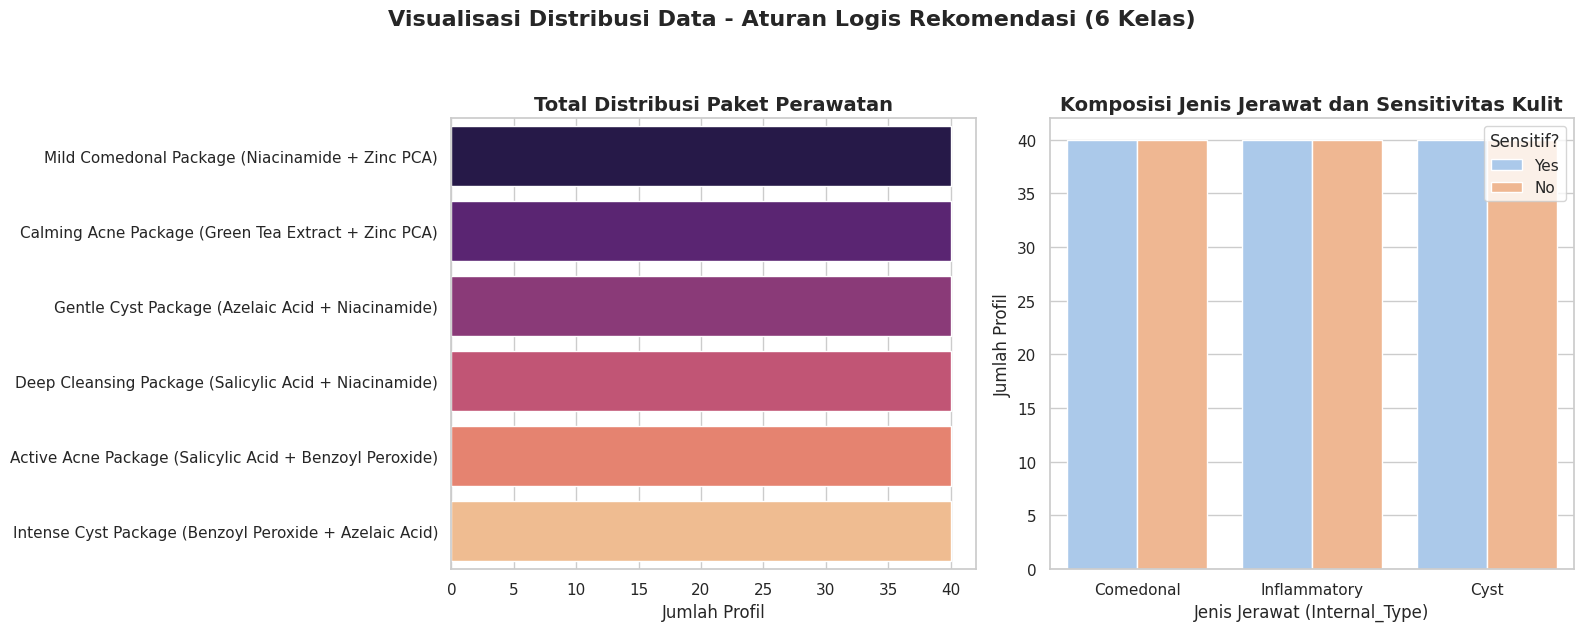

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualisasi Distribusi Data - Aturan Logis Rekomendasi (6 Kelas)', fontsize=16, fontweight='bold', y=1.05)

sns.countplot(
    y='Eksperimen_Target',
    data=df,
    order=df['Eksperimen_Target'].value_counts().index,
    palette='magma',
    ax=axes[0]
)
axes[0].set_title('Total Distribusi Paket Perawatan', fontsize=14)
axes[0].set_xlabel('Jumlah Profil', fontsize=12)
axes[0].set_ylabel('')

sns.countplot(
    x='Internal_Type',
    hue='Sensitivity',
    data=df,
    palette='pastel',
    ax=axes[1]
)
axes[1].set_title('Komposisi Jenis Jerawat dan Sensitivitas Kulit', fontsize=14)
axes[1].set_xlabel('Jenis Jerawat (Internal_Type)', fontsize=12)
axes[1].set_ylabel('Jumlah Profil', fontsize=12)
axes[1].legend(title='Sensitif?')

plt.tight_layout()
plt.show()

Testing (manual)

In [ ]:
data_baru = pd.DataFrame({
    'Age_Group': ['25-36'],
    'Skin_Type': ['Oily'],
    'Skin_Subtype': ['Oily'],
    'Sensitivity': ['No'],
    'Internal_Type': ['Cyst']
})

print(data_baru.to_string(index=False))

data_baru_processed = preprocessor.transform(data_baru)

prediksi_encoded = rf_model.predict(data_baru_processed)

prediksi_label = label_encoder.inverse_transform(prediksi_encoded)

print(f"Rekomendasi Perawatan: {prediksi_label[0]}")

Age_Group Skin_Type Skin_Subtype Sensitivity Internal_Type
    25-36      Oily         Oily          No          Cyst
Rekomendasi Perawatan: Intense Cyst Package (Benzoyl Peroxide + Azelaic Acid)


In [ ]:
import joblib

joblib.dump(preprocessor, 'preprocessor_rekomendasi.joblib')

joblib.dump(label_encoder, 'label_encoder_rekomendasi.joblib')

joblib.dump(rf_model, 'rf_model_rekomendasi.joblib')

print("✅ Semua komponen model berhasil disimpan dalam format .joblib!")

✅ Semua komponen model berhasil disimpan dalam format .joblib!
